In [1]:
import pennylane as qp
import numpy as np
import matplotlib.pyplot as plt

dev = qp.device("default.qubit", wires=1)

In [2]:
@qp.qnode(dev)
def circuit():
    # IMPLEMENT THE CIRCUIT IN THE PICTURE AND MEASURE PAULI Y
    qp.RX(np.pi/4, 0)
    qp.Hadamard(0)
    qp.PauliZ(0)

    return qp.expval(qp.PauliY(0))

In [3]:
print(circuit())

-0.7071067811865471


In [4]:
# An array to store your results
shot_results = []

# Different numbers of shots
shot_values = [100, 1000, 10000, 100000, 1000000]

for shots in shot_values:
    # CREATE A DEVICE, CREATE A QNODE, AND RUN IT
    dev = qp.device("default.qubit", wires=1)

    @qp.qnode(dev)
    def circuit():
        # IMPLEMENT THE CIRCUIT IN THE PICTURE AND MEASURE PAULI Y
        qp.RX(np.pi/4, 0)
        qp.Hadamard(0)
        qp.PauliZ(0)

        return qp.expval(qp.PauliY(0))

    circuit._set_shots(shots=shots)

    # STORE RESULT IN SHOT_RESULTS ARRAY
    shot_results.append(circuit())

print(qp.math.unwrap(shot_results))

[-0.76, -0.732, -0.7026, -0.70696, -0.707734]


In [5]:
dev = qp.device("default.qubit", wires=1)

In [6]:
@qp.qnode(dev)
def circuit():
    qp.RX(np.pi / 4, wires=0)
    qp.Hadamard(wires=0)
    qp.PauliZ(wires=0)

    # RETURN THE MEASUREMENT SAMPLES OF THE CORRECT OBSERVABLE
    return qp.sample(qp.PauliY(0))

circuit._set_shots(100000)

In [7]:
def compute_expval_from_samples(samples):
    """Compute the expectation value of an observable given a set of
    sample outputs. You can assume that there are two possible outcomes,
    1 and -1.

    Args:
        samples (np.array[float]): 100000 samples representing the results of
            running the above circuit.

    Returns:
        float: the expectation value computed based on samples.
    """

    estimated_expval = 0
    numOne = (samples == 1).sum()
    numNegOne = (samples == -1).sum()

    # USE THE SAMPLES TO ESTIMATE THE EXPECTATION VALUE
    estimated_expval = numOne - numNegOne
    estimated_expval /= samples.size

    return estimated_expval

In [8]:
samples = circuit()
print(compute_expval_from_samples(samples))

-0.7047


In [9]:
def variance_experiment(n_shots):
    """Run an experiment to determine the variance in an expectation
    value computed with a given number of shots.

    Args:
        n_shots (int): The number of shots

    Returns:
        float: The variance in expectation value we obtain running the
        circuit 100 times with n_shots shots each.
    """

    # To obtain a variance, we run the circuit multiple times at each shot value.
    n_trials = 100

    # DECORATE THE CIRCUIT BELOW TO CREATE A QNODE
    @qp.qnode(dev)
    def circuit():
        qp.Hadamard(wires=0)
        return qp.expval(qp.PauliZ(wires=0))

    circuit._set_shots(n_shots)

    # RUN THE QNODE N_TRIALS TIMES AND RETURN THE VARIANCE OF THE RESULTS
    shot_results = []
    for i in range(n_trials):
        shot_results.append(circuit())

    mean = sum(shot_results) / n_trials
    variance = sum((r - mean) ** 2 for r in shot_results) / n_trials
    
    return variance

In [10]:
variance_experiment(100)

np.float64(0.007602360000000003)

In [11]:
def variance_scaling(n_shots):
    """Once you have determined how the variance in expectation value scales
    with the number of shots, complete this function to programmatically
    represent the relationship.

    Args:
        n_shots (int): The number of shots

    Returns:
        float: The variance in expectation value we expect to see when we run
        an experiment with n_shots shots.
    """

    estimated_variance = 1 / n_shots
    return estimated_variance

In [12]:
def plotter(shot_vals, results_experiment, results_scaling):
    plt.figure(figsize=(8, 6))

    plt.loglog(shot_vals, results_experiment, 'o-', label='Experimental variance')
    plt.loglog(shot_vals, results_scaling, 's--', label='Theoretical scaling')

    plt.xlabel('Number of shots')
    plt.ylabel('Variance')
    plt.title('Variance in expectation value vs. number of shots')
    plt.legend()
    plt.grid(True, which='both', ls='--', alpha=0.5)

    plt.show()

    return plt

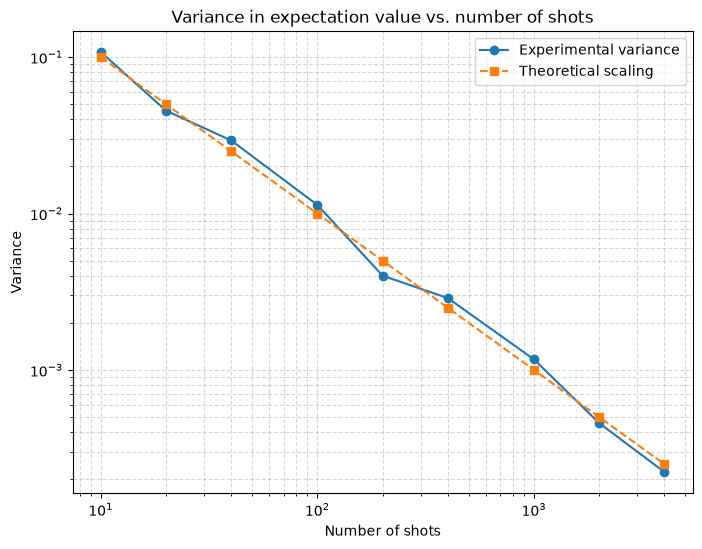

In [13]:
# Various numbers of shots; you can change this
shot_vals = [10, 20, 40, 100, 200, 400, 1000, 2000, 4000]

# Used to plot your results
results_experiment = [variance_experiment(shots) for shots in shot_vals]
results_scaling = [variance_scaling(shots) for shots in shot_vals]
plot = plotter(shot_vals, results_experiment, results_scaling)